# CAPEN attention temperature: degree vs γ

Pre-softmax temperatures for relations `11 / 12 / 21 / 22`:

- **degree**: each logit row is divided by its support count $n_i = \sum_j M_{ij}$
- **gamma**: every logit in relation $r\to s$ is divided by a single $\gamma_{rs}$

Here $\gamma_{rs}$ is estimated as the **mean nonempty row degree** of that support on a train-cache subsample — the natural global approximation to degree-norm.

Uses the same star / kNN caches as training.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path("..").resolve()
for p in (REPO, REPO / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from cpen.utils.attention_temperature import estimate_attention_gammas_from_cache

DATA_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging")
STAR_RADIUS = 0.15
NUM_PARTICLES = 128
N_JETS = 512
SEED = 42

# CAPEN-Llama jets use all-to-all M_11; plain CAPEN uses SᵀS.
ALL_TO_ALL_11 = True

In [2]:
gammas, summaries = estimate_attention_gammas_from_cache(
    data_root=str(DATA_ROOT),
    split="train",
    radius=STAR_RADIUS,
    num_particles=NUM_PARTICLES,
    n_jets=N_JETS,
    seed=SEED,
    all_to_all_particle_attention=ALL_TO_ALL_11,
)

print("Recommended --attention-normalization gamma values (mean row degrees):")
print(
    f"  --gamma-11 {gammas.gamma_11:.4g} "
    f"--gamma-12 {gammas.gamma_12:.4g} "
    f"--gamma-21 {gammas.gamma_21:.4g} "
    f"--gamma-22 {gammas.gamma_22:.4g}"
)
print()
for rel, s in summaries.items():
    print(
        f"M_{rel}: n_rows={s['n_rows']:,}  "
        f"mean={s['mean']:.3f}  median={s['median']:.3f}  "
        f"std={s['std']:.3f}  min={s['min']:.0f}  max={s['max']:.0f}"
    )

[graphs] split=train mode=star-cache mmap /scratch/gpfs/BHANIN/jdezoort/datasets/toptagging/processed/star-r0p1500/n128/train.pt
[graphs] split=train star-cache mmap indexed 1211000/1211000 jets
Recommended --attention-normalization gamma values (mean row degrees):
  --gamma-11 54.14 --gamma-12 8.494 --gamma-21 8.494 --gamma-22 5.915

M_11: n_rows=24,809  mean=54.141  median=53.000  std=16.458  min=9  max=104
M_12: n_rows=24,809  mean=8.494  median=7.000  std=6.269  min=1  max=35
M_21: n_rows=24,809  mean=8.494  median=7.000  std=6.269  min=1  max=35
M_22: n_rows=65,536  mean=5.915  median=1.000  std=8.792  min=1  max=57


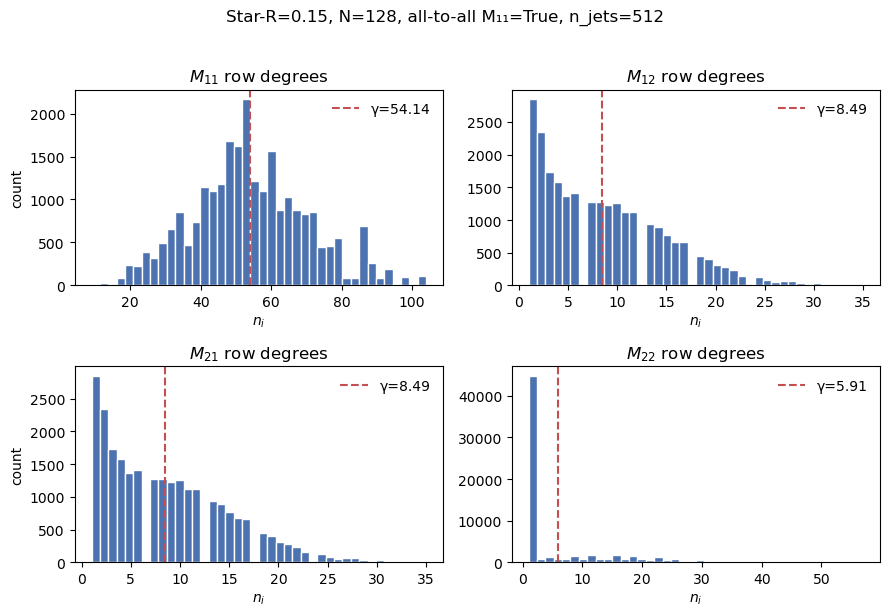

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=False)
for ax, rel in zip(axes.ravel(), ("11", "12", "21", "22")):
    vals = summaries[rel]["degrees"]
    ax.hist(vals, bins=min(40, max(5, int(np.sqrt(max(len(vals), 1))))), color="#4C72B0", edgecolor="white")
    ax.axvline(summaries[rel]["mean"], color="#C44E52", ls="--", lw=1.5, label=f"γ={summaries[rel]['mean']:.2f}")
    ax.set_title(f"$M_{{{rel}}}$ row degrees")
    ax.set_xlabel("$n_i$")
    ax.legend(frameon=False)
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
fig.suptitle(
    f"Star-R={STAR_RADIUS:g}, N={NUM_PARTICLES}, "
    f"all-to-all M₁₁={ALL_TO_ALL_11}, n_jets={N_JETS}",
    y=1.02,
)
fig.tight_layout()
plt.show()

## How to use in training

```bash
# Per-row degree temperature (no estimate needed)
python scans/testing/test_cpen_toptagging.py \\
  --model capen-llama --attention-normalization degree ...

# Global γ = mean row degree (auto-estimate from train cache)
python scans/testing/test_cpen_toptagging.py \\
  --model capen-llama --attention-normalization gamma \\
  --estimate-gamma-rs --gamma-estimate-jets 512 ...

# Or paste the printed --gamma-11/12/21/22 values explicitly
```

**Note:** for `capen-llama` with all-to-all particles, $M_{11}$ row degree is $\approx N_{\mathrm{valid}}$ (often $\sim N$), so $\gamma_{11}$ will be large relative to local star relations.